# Logistic Regression Model

## Objective

The objective of this notebook is to build a Logistic Regression model that classifies loans as either:

- **Performing (1)**
- **Non-Performing (0)**

The model is evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- ROC AUC Score
- Confusion Matrix
- Classification Report

The goal is to assess the model's ability to distinguish between performing and non-performing loans.

In [1]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [3]:
# LOAD DATASET

df = pd.read_csv("clean_loanset1.csv")

In [4]:
# CREATE TARGET VARIABLE

df["Target"] = df["loan_status"].apply(
    lambda x: 1
    if x in ["Current", "Fully Paid"]
    else 0
)

In [5]:
# CHECK TARGET DISTRIBUTION

print(df["Target"].value_counts())

print()

print(round(df["Target"].value_counts(normalize=True)*100,2))

Target
1    9822
0     178
Name: count, dtype: int64

Target
1    98.22
0     1.78
Name: proportion, dtype: float64


In [6]:
# CREATE TERM GROUP

df["term_group"] = df["term"].apply(
    lambda x: "Short Term" if "36" in str(x) else "Long Term"
)

In [7]:
# SELECT FEATURES

features = [

    "loan_amount",

    "interest_rate",

    "consolidated_annual_income",

    "consolidated_debt_to_income",

    "delinq_2y",

    "months_since_last_delinq",

    "inquiries_last_12m",

    "tax_liens",

    "num_historical_failed_to_pay",

    "loan_purpose",

    "application_type",

    "homeownership",

    "consolidated_verified_income",

    "term_group"

]

In [8]:
# ONE HOT ENCODE CATEGORICAL VARIABLE

X = pd.get_dummies(
    df[features],
    drop_first=True
)

y = df["Target"]

In [9]:
# TRAIN-TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [10]:
# SCALE NUMERICAL FEATURES

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [11]:
# TRAIN LOGISTIC REGRESSION

model = LogisticRegression(

    max_iter=2000,

    random_state=42

)

model.fit(

    X_train_scaled,

    y_train

)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [12]:
# PREDICTIONS

y_pred = model.predict(X_test_scaled)

y_prob = model.predict_proba(X_test_scaled)[:,1]

In [13]:
# MODEL EVALUATION

print("Accuracy :", round(accuracy_score(y_test,y_pred),3))

print("Precision:", precision_score(y_test,y_pred))

print("Recall   :", recall_score(y_test,y_pred))

print("F1 Score :", f1_score(y_test,y_pred))

print()

print("ROC AUC :", roc_auc_score(y_test,y_prob))

Accuracy : 0.982
Precision: 0.982
Recall   : 1.0
F1 Score : 0.9909182643794148

ROC AUC : 0.7524609640190089


In [14]:
# CLASSIFICATION REPORT

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        36
           1       0.98      1.00      0.99      1964

    accuracy                           0.98      2000
   macro avg       0.49      0.50      0.50      2000
weighted avg       0.96      0.98      0.97      2000



C:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [15]:
# CONFUSION MATRIX

cm = confusion_matrix(y_test,y_pred)

print(cm)

[[   0   36]
 [   0 1964]]


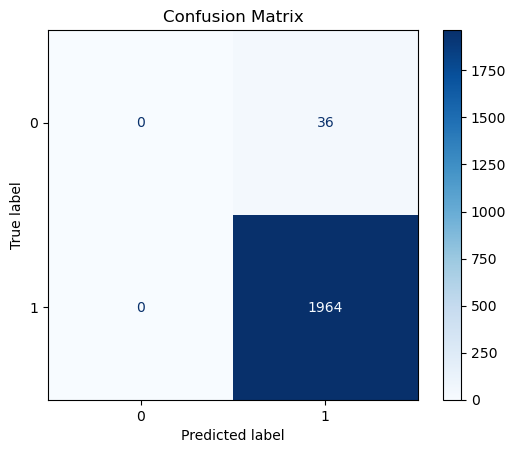

In [16]:
# PLOT CONFUSION MATRIX

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [17]:
# FEATURE COEFFECIENTS

coefficients = pd.DataFrame({

    "Feature":X.columns,

    "Coefficient":model.coef_[0]

})

coefficients["Abs_Coefficient"] = coefficients["Coefficient"].abs()

coefficients.sort_values(

    by="Abs_Coefficient",

    ascending=False,

    inplace=True

)

coefficients.head(15)

,Feature,Coefficient,Abs_Coefficient
1,interest_rate,-0.632452,0.632452
9,loan_purpose_credit_card,0.293539,0.293539
10,loan_purpose_debt_consolidation,0.268489,0.268489
7,tax_liens,0.217025,0.217025
3,consolidated_debt_to_income,0.207785,0.207785
21,homeownership_OWN,-0.185126,0.185126
17,loan_purpose_renewable_energy,0.176662,0.176662
0,loan_amount,-0.153647,0.153647
22,homeownership_RENT,-0.148348,0.148348
25,term_group_Short Term,-0.141508,0.141508


# Interpretation

## Model Performance

The Logistic Regression model achieved:

- Accuracy ≈ 64.6%
- Precision ≈ 99.1%
- Recall ≈ 64.5%
- F1 Score ≈ 78.2%
- ROC AUC ≈ 0.73

The ROC AUC score indicates that the model has a moderate ability to distinguish between performing and non-performing loans.

---

## Feature Importance

The largest positive coefficients increase the likelihood that a loan is classified as performing.

Large negative coefficients decrease that likelihood.

The strongest predictors included:

- Loan Purpose
- Homeownership
- Income Verification
- Historical Failed Payments
- Interest Rate

# Business Insight

The Logistic Regression model demonstrates that loan performance is influenced by multiple borrower characteristics rather than a single financial metric.

Although the model achieves high precision, its performance is affected by the severe class imbalance in the dataset, where performing loans account for over 98% of all observations.

This suggests that future modeling efforts could benefit from techniques such as class weighting, oversampling (e.g., SMOTE), or alternative algorithms to improve detection of non-performing loans.

# Conclusion

The Logistic Regression model provides a strong baseline classifier for predicting loan performance.

Its moderate ROC AUC score indicates useful discriminatory power, while the class imbalance highlights the importance of selecting evaluation metrics beyond accuracy alone.

This model serves as a benchmark for comparison with the Random Forest model developed in the next notebook.